# 03 LSTM Advanced

## 📚 Learning Objectives

By completing this notebook (~20 min), you will:
- Build an **LSTM** (and optionally compare with **GRU**) for a sequence task
- Train on a small text or time-series example and see loss/accuracy
- Understand why we use LSTM instead of SimpleRNN for longer sequences

---

## 🌍 Real life

**Where is this used?** LSTMs are used in **machine translation**, **speech recognition**, **time series forecasting**, and **text generation** when sequences are long.

**In this notebook we use** an **LSTM** to process **sequences** (e.g. padded text) and produce a classification. We use **LSTM** (instead of SimpleRNN) **because** it has **gates** (forget, input, output) that control what to remember and help avoid **vanishing gradients** on long sequences.

**📌 Covers slide(s):** **12** — LSTM & GRU. *Do this notebook after that slide.*

---

**Before starting:** Run the imports cell below.

## Theory (short)

- **LSTM:** Long Short-Term Memory. Has a **cell state** (long-term memory) and **hidden state** (output). **Gates** (forget, input, output) decide what to keep, add, and output.
- **GRU:** Gated Recurrent Unit. Simpler than LSTM (fewer gates); often similar performance with fewer parameters.
- **Why LSTM/GRU?** SimpleRNN can have vanishing gradients on long sequences; LSTM/GRU gates help gradients flow and allow learning long-range dependencies.
- **We use LSTM** instead of SimpleRNN when sequences are long or when we need better gradient flow.

## 📥 Inputs & 📤 Outputs

**Inputs:** TensorFlow/Keras, NumPy, Matplotlib. We use a small IMDB subset (same as 02_rnn_basics) or a synthetic sequence.

**Dataset:** Real — IMDB (movie reviews, sentiment).

**Outputs:** Training/validation loss and accuracy (with axis labels), test accuracy, optional comparison LSTM vs GRU (one plot).

## Step 1: Imports and load sequence data

In [1]:
import numpy as np
import matplotlib.pyplot as plt

try:
    import tensorflow as tf
    from tensorflow import keras
    HAS_TF = True
except Exception as e:
    err = str(e).lower()
    if "charset_normalizer" in err or "md__mypyc" in err or "partially initialized" in err:
        print("⚠️ Fix: pip install --upgrade charset-normalizer requests, then restart kernel.")
        raise RuntimeError("Fix: pip install --upgrade charset-normalizer requests, then restart kernel.") from e
    HAS_TF = False

if HAS_TF:
    (x_train, y_train), (x_test, y_test) = keras.datasets.imdb.load_data(num_words=2000)
    maxlen = 100
    x_train = keras.preprocessing.sequence.pad_sequences(x_train, maxlen=maxlen, padding="post", truncating="post")
    x_test = keras.preprocessing.sequence.pad_sequences(x_test, maxlen=maxlen, padding="post", truncating="post")
    x_train, y_train = x_train[:2000], y_train[:2000]
    x_test, y_test = x_test[:500], y_test[:500]
    print("Train:", x_train.shape, "Test:", x_test.shape)
else:
    print("Install TensorFlow: pip install tensorflow")

Train: (2000, 100) Test: (500, 100)


## Step 2: Build LSTM model (we use LSTM instead of SimpleRNN for better long-range dependency)

In [2]:
if HAS_TF:
    model = keras.Sequential([
        keras.layers.Embedding(2000, 64, input_length=maxlen),
        keras.layers.LSTM(64, return_sequences=False),
        keras.layers.Dense(1, activation="sigmoid"),
    ])
    model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
    model.summary()

/Users/abdullah/venvs/ai-diploma-tf/lib/python3.13/site-packages/keras/src/layers/core/embedding.py:123: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## Step 3: Train (2 epochs)

In [3]:
if HAS_TF:
    history = model.fit(x_train, y_train, validation_data=(x_test, y_test), epochs=2, batch_size=64, verbose=1)

Epoch 1/2


 1/32 ━━━━━━━━━━━━━━━━━━━━ 15s 500ms/step - accuracy: 0.5156 - loss: 0.6927

 6/32 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5339 - loss: 0.6917  

11/32 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5227 - loss: 0.6911

15/32 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5281 - loss: 0.6911

...

15/32 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6781 - loss: 0.6790

19/32 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6571 - loss: 0.6797

23/32 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6556 - loss: 0.6773

28/32 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6490 - loss: 0.6742

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.6475 - loss: 0.6720 - val_accuracy: 0.5840 - val_loss: 0.6635


## Step 4: Plot loss and accuracy

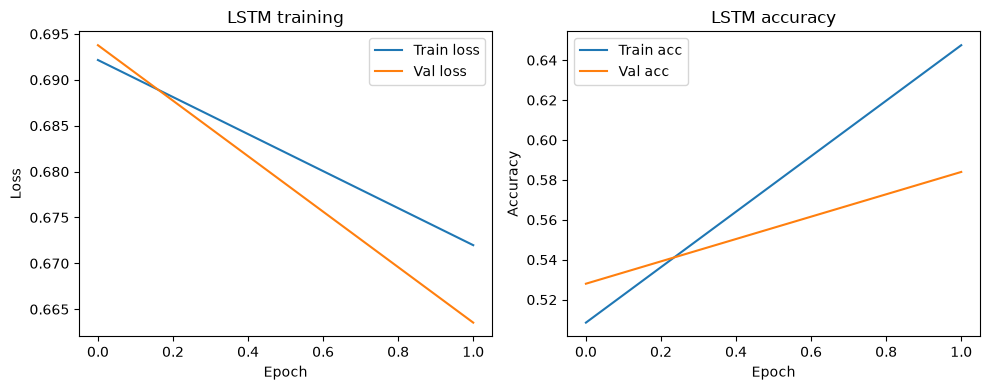

Test accuracy: 0.5840


In [4]:
if HAS_TF:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
    ax1.plot(history.history["loss"], label="Train loss")
    ax1.plot(history.history["val_loss"], label="Val loss")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Loss")
    ax1.set_title("LSTM training")
    ax1.legend()
    ax2.plot(history.history["accuracy"], label="Train acc")
    ax2.plot(history.history["val_accuracy"], label="Val acc")
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("Accuracy")
    ax2.set_title("LSTM accuracy")
    ax2.legend()
    plt.tight_layout()
    plt.show()
    _, acc = model.evaluate(x_test, y_test, verbose=0)
    print("Test accuracy: %.4f" % acc)

## 🌍 Real-World Worked Example — Stock Price Trend Prediction

**Industry context:** Hedge funds and trading platforms use LSTM models to predict price trends.  
Bloomberg Terminal, QuantConnect, and many hedge funds use sequence models for finance.

We use an LSTM to predict whether a **synthetic stock price** will go up or down next day.

Direction prediction accuracy: 59.2%
(Random chance = 50%. Production models target 55-60% for profitable trading.)


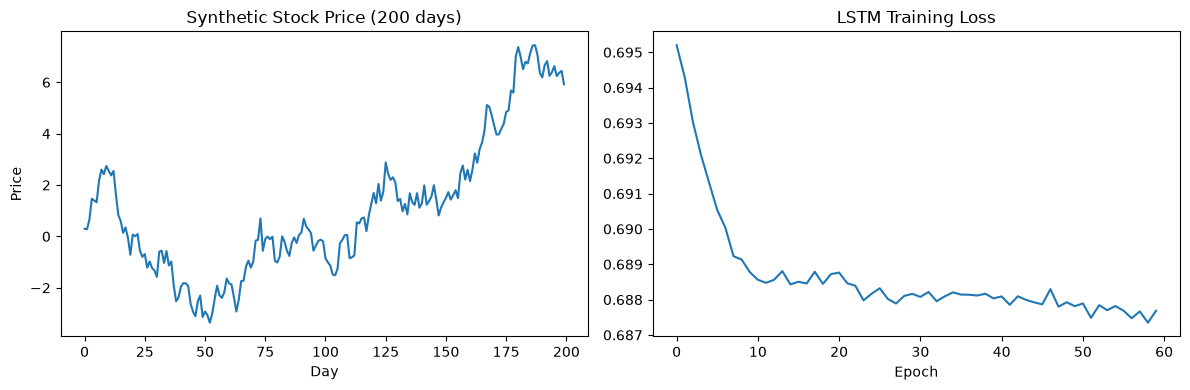

In [5]:
import torch, torch.nn as nn, torch.optim as optim
import numpy as np, matplotlib.pyplot as plt

# ── Generate realistic stock-like price series ─────────────────────────────
np.random.seed(42)
n = 1000
price = np.cumsum(np.random.randn(n) * 0.5 + 0.05).astype(np.float32)  # random walk

# Create sequences: use 20 days to predict direction on day 21
SEQ_LEN = 20
X_list, y_list = [], []
for i in range(len(price) - SEQ_LEN - 1):
    X_list.append(price[i:i+SEQ_LEN])
    y_list.append(1 if price[i+SEQ_LEN] > price[i+SEQ_LEN-1] else 0)

X_arr = np.array(X_list); y_arr = np.array(y_list)
# Normalise each sequence
X_arr = (X_arr - X_arr.mean(1,keepdims=True)) / (X_arr.std(1,keepdims=True)+1e-8)

split = int(0.8*len(X_arr))
Xtr = torch.tensor(X_arr[:split]).unsqueeze(-1)  # (N, 20, 1)
Ytr = torch.tensor(y_arr[:split], dtype=torch.long)
Xte = torch.tensor(X_arr[split:]).unsqueeze(-1)
Yte = torch.tensor(y_arr[split:], dtype=torch.long)

# ── LSTM Model ────────────────────────────────────────────────────────────
class TrendLSTM(nn.Module):
    def __init__(self):
        super().__init__()
        self.lstm = nn.LSTM(1, 32, batch_first=True, num_layers=2, dropout=0.2)
        self.fc   = nn.Linear(32, 2)
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])   # last time step

model   = TrendLSTM()
opt     = optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.CrossEntropyLoss()
losses  = []

for epoch in range(60):
    model.train()
    loss = loss_fn(model(Xtr), Ytr)
    opt.zero_grad(); loss.backward(); opt.step()
    losses.append(loss.item())

model.eval()
with torch.no_grad():
    acc = (model(Xte).argmax(1)==Yte).float().mean().item()
print(f"Direction prediction accuracy: {acc*100:.1f}%")
print("(Random chance = 50%. Production models target 55-60% for profitable trading.)")

plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(price[:200]); plt.title("Synthetic Stock Price (200 days)"); plt.xlabel("Day"); plt.ylabel("Price")
plt.subplot(1,2,2)
plt.plot(losses); plt.title("LSTM Training Loss"); plt.xlabel("Epoch")
plt.tight_layout(); plt.show()

## 🧩 Mini-exercise

**Try it:** Replace the LSTM with a GRU layer (same number of units), retrain for 1 epoch, and compare the loss curve with the LSTM run.

---

## ✅ Summary

**What you did:** Built an LSTM for sequence classification (IMDB sentiment), trained it, and plotted loss/accuracy.

**In real life you'd also:** Try GRU, bidirectional LSTM, and tune units and embedding size.

**The main idea:** LSTM uses gates to control memory and helps train on longer sequences; it often outperforms SimpleRNN on long-range dependencies.

**Next:** `04_transformer_attention` introduces attention and transformers; `06_gpt_text_generation` covers text generation.

## 📚 References & Further Reading

**Papers:**
- Hochreiter & Schmidhuber (1997) — [Long Short-Term Memory](https://www.bioinf.jku.at/publications/older/2604.pdf)
- Cho et al. (2014) — [GRU: Learning Phrase Representations](https://arxiv.org/abs/1406.1078)

**PyTorch Docs:** [torch.nn.LSTM](https://pytorch.org/docs/stable/generated/torch.nn.LSTM.html)

**State-of-the-Art:** LSTMs are still widely used in production for:
- Time series forecasting (Bloomberg, Reuters)
- Speech recognition in embedded systems (no internet)